# Ddri Station Clustering Baseline

- 범위: 강남구 따릉이 대여소
- 학습 데이터: 2023-01-01 ~ 2024-12-31
- 테스트 데이터: 2025-01-01 ~ 2025-12-31
- 1차 기준 대여소: 2023~2025 공통 169개 대여소


## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path('/Users/cheng80/Desktop/ddri_work')
DATA_DIR = BASE_DIR / '3조 공유폴더'
OUTPUT_DATA_DIR = BASE_DIR / 'works' / '01_clustering' / '06_data'
OUTPUT_IMG_DIR = BASE_DIR / 'works' / '01_clustering' / '07_images'

OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

## 2. Input Paths

In [2]:
rental_2023_files = sorted((DATA_DIR / '2023 강남구 따릉이 이용정보').glob('*.csv'))
rental_2024_files = sorted((DATA_DIR / '2024 강남구 따릉이 이용정보').glob('*.csv'))
rental_2025_files = sorted((DATA_DIR / '2025 강남구 따릉이 이용정보').glob('*.csv'))

station_master_files = {
    2023: DATA_DIR / '강남구 대여소 정보 (2023~2025)' / '2023_강남구_대여소.csv',
    2024: DATA_DIR / '강남구 대여소 정보 (2023~2025)' / '2024_강남구_대여소.csv',
    2025: DATA_DIR / '강남구 대여소 정보 (2023~2025)' / '2025_강남구_대여소.csv',
}

len(rental_2023_files), len(rental_2024_files), len(rental_2025_files)

(12, 12, 12)

## 3. Build Common Station Master

In [3]:
station_frames = {}
station_id_sets = {}

for year, path in station_master_files.items():
    df = pd.read_csv(path)
    df['대여소번호'] = pd.to_numeric(df['대여소번호'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['대여소번호']).copy()
    df['대여소번호'] = df['대여소번호'].astype(int)
    station_frames[year] = df
    station_id_sets[year] = set(df['대여소번호'])

common_station_ids = sorted(set.intersection(*station_id_sets.values()))
common_station_ids[:10], len(common_station_ids)

([2301, 2302, 2303, 2304, 2305, 2306, 2307, 2308, 2309, 2310], 169)

In [4]:
station_master = (
    station_frames[2025]
    .loc[station_frames[2025]['대여소번호'].isin(common_station_ids), ['대여소번호', '대여소명', '자치구', '주소', '위도', '경도']]
    .drop_duplicates('대여소번호')
    .sort_values('대여소번호')
    .reset_index(drop=True)
)

station_master.head()

,대여소번호,대여소명,자치구,주소,위도,경도
0,2301,현대고등학교 건너편,강남구,서울특별시 강남구 압구정로 134,37.524071,127.021790
1,2302,교보타워 버스정류장(신논현역 3번출구 후면),강남구,서울특별시 강남구 봉은사로 지하 102,37.505581,127.024277
2,2303,논현역 10번출구,강남구,서울특별시 강남구 학동로 지하 102,37.511372,127.021461
3,2304,대현그린타워,강남구,서울특별시 강남구 언주로 626,37.511627,127.035652
4,2305,MCM 본사 직영점 앞,강남구,서울특별시 강남구 언주로 734,37.520641,127.034508


## 4. Load Rental Data

In [5]:
RENTAL_COLS = ['대여일시', '대여 대여소번호', '반납일시', '반납대여소번호', '이용시간(분)', '이용거리(M)']

def load_rental_files(paths):
    frames = []
    for path in paths:
        df = pd.read_csv(path, usecols=RENTAL_COLS)
        df['대여일시'] = pd.to_datetime(df['대여일시'])
        df['대여 대여소번호'] = pd.to_numeric(df['대여 대여소번호'], errors='coerce').astype('Int64')
        df = df.dropna(subset=['대여일시', '대여 대여소번호']).copy()
        df['대여 대여소번호'] = df['대여 대여소번호'].astype(int)
        df = df[df['대여 대여소번호'].isin(common_station_ids)].copy()
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

train_df = load_rental_files(rental_2023_files + rental_2024_files)
test_df = load_rental_files(rental_2025_files)

train_df.shape, test_df.shape

((1980434, 6), (839417, 6))

## 5. Build Clustering Features

In [6]:
def build_station_features(df):
    work = df.copy()
    work['date'] = work['대여일시'].dt.date
    work['hour'] = work['대여일시'].dt.hour
    work['weekday'] = work['대여일시'].dt.weekday
    work['is_weekend'] = work['weekday'] >= 5
    work['is_peak'] = work['hour'].isin([7, 8, 9, 18, 19, 20])
    work['is_night'] = work['hour'].isin([22, 23, 0, 1, 2, 3, 4, 5])

    daily = (
        work.groupby(['대여 대여소번호', 'date'])
        .size()
        .reset_index(name='daily_rental_count')
    )

    avg_rental = daily.groupby('대여 대여소번호')['daily_rental_count'].mean()
    rental_std = daily.groupby('대여 대여소번호')['daily_rental_count'].std().fillna(0)

    weekday_avg = (
        work.loc[~work['is_weekend']]
        .groupby(['대여 대여소번호', 'date'])
        .size()
        .groupby('대여 대여소번호')
        .mean()
    )

    weekend_avg = (
        work.loc[work['is_weekend']]
        .groupby(['대여 대여소번호', 'date'])
        .size()
        .groupby('대여 대여소번호')
        .mean()
    )

    total = work.groupby('대여 대여소번호').size()
    peak = work.loc[work['is_peak']].groupby('대여 대여소번호').size()
    night = work.loc[work['is_night']].groupby('대여 대여소번호').size()

    features = pd.DataFrame({
        'station_id': avg_rental.index,
        'avg_rental': avg_rental.values,
        'rental_std': rental_std.reindex(avg_rental.index).values,
        'weekday_avg': weekday_avg.reindex(avg_rental.index).fillna(0).values,
        'weekend_avg': weekend_avg.reindex(avg_rental.index).fillna(0).values,
        'peak_ratio': (peak / total).reindex(avg_rental.index).fillna(0).values,
        'night_ratio': (night / total).reindex(avg_rental.index).fillna(0).values,
    })
    features['weekday_weekend_gap'] = features['weekday_avg'] - features['weekend_avg']
    return features.sort_values('station_id').reset_index(drop=True)

train_features = build_station_features(train_df)
train_features.head()

,station_id,avg_rental,rental_std,weekday_avg,weekend_avg,peak_ratio,night_ratio,weekday_weekend_gap
0,2301,26.495146,21.522928,22.990272,35.198068,0.355127,0.165524,-12.207795
1,2302,20.392958,10.097505,21.726378,17.039604,0.339112,0.222598,4.686774
2,2303,26.258550,13.436004,28.693487,20.177033,0.394686,0.158635,8.516453
3,2304,9.085260,6.720163,9.855422,7.108247,0.411643,0.126133,2.747174
4,2305,7.590711,4.469955,8.909804,3.832402,0.410516,0.075335,5.077402


## 6. Save Feature Table

In [7]:
feature_path = OUTPUT_DATA_DIR / 'ddri_station_cluster_features_train_2023_2024.csv'
train_features.to_csv(feature_path, index=False)
feature_path

PosixPath('/Users/cheng80/Desktop/ddri_work/works/01_clustering/06_data/ddri_station_cluster_features_train_2023_2024.csv')

## 7. KMeans Search

In [8]:
feature_cols = [
    'avg_rental',
    'rental_std',
    'weekday_avg',
    'weekend_avg',
    'peak_ratio',
    'night_ratio',
    'weekday_weekend_gap',
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(train_features[feature_cols])

search_rows = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    search_rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(X_scaled, labels),
    })

k_search_df = pd.DataFrame(search_rows)
k_search_df

,k,inertia,silhouette
0,2,702.846403,0.426219
1,3,559.836742,0.272038
2,4,452.350952,0.287453
3,5,386.764824,0.255323
4,6,330.315686,0.280360


## 8. Elbow / Silhouette Plots

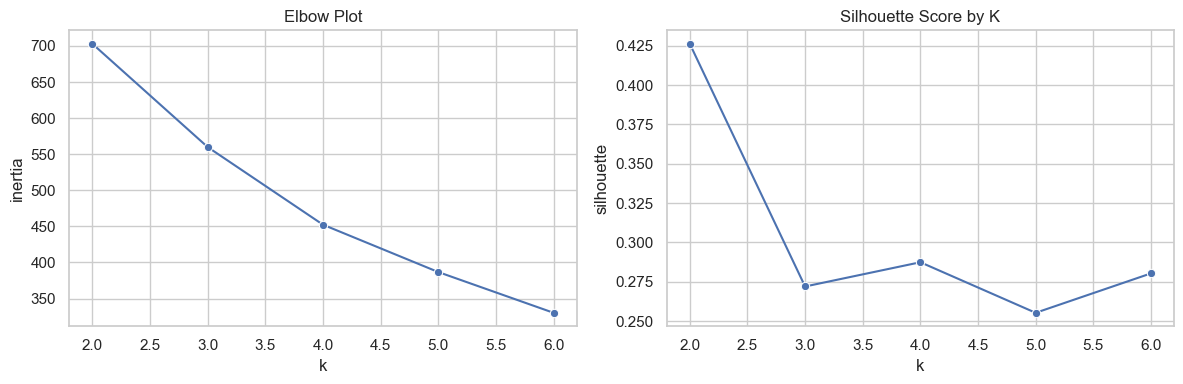

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=k_search_df, x='k', y='inertia', marker='o', ax=axes[0])
sns.lineplot(data=k_search_df, x='k', y='silhouette', marker='o', ax=axes[1])
axes[0].set_title('Elbow Plot')
axes[1].set_title('Silhouette Score by K')
plt.tight_layout()
plt.show()

## 9. Final KMeans and PCA

In [10]:
FINAL_K = 3

final_model = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
train_features['cluster'] = final_model.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
pca_points = pca.fit_transform(X_scaled)
train_features['pca_1'] = pca_points[:, 0]
train_features['pca_2'] = pca_points[:, 1]

train_features.head()

,station_id,avg_rental,rental_std,weekday_avg,weekend_avg,peak_ratio,night_ratio,weekday_weekend_gap,cluster,pca_1,pca_2
0,2301,26.495146,21.522928,22.990272,35.198068,0.355127,0.165524,-12.207795,2,2.023156,2.709971
1,2302,20.392958,10.097505,21.726378,17.039604,0.339112,0.222598,4.686774,1,0.363253,1.948712
2,2303,26.258550,13.436004,28.693487,20.177033,0.394686,0.158635,8.516453,2,1.854683,0.318049
3,2304,9.085260,6.720163,9.855422,7.108247,0.411643,0.126133,2.747174,1,-1.367184,-0.706604
4,2305,7.590711,4.469955,8.909804,3.832402,0.410516,0.075335,5.077402,0,-1.662321,-1.794081


## 10. Cluster Summary and Visuals

In [11]:
cluster_summary = train_features.groupby('cluster')[feature_cols].mean().round(3)
cluster_summary

,avg_rental,rental_std,weekday_avg,weekend_avg,peak_ratio,night_ratio,weekday_weekend_gap
cluster,,,,,,,
0,17.167,9.604,18.964,12.608,0.413,0.106,6.355
1,10.325,6.114,10.904,8.844,0.351,0.152,2.060
2,34.769,17.710,36.890,29.459,0.373,0.139,7.431


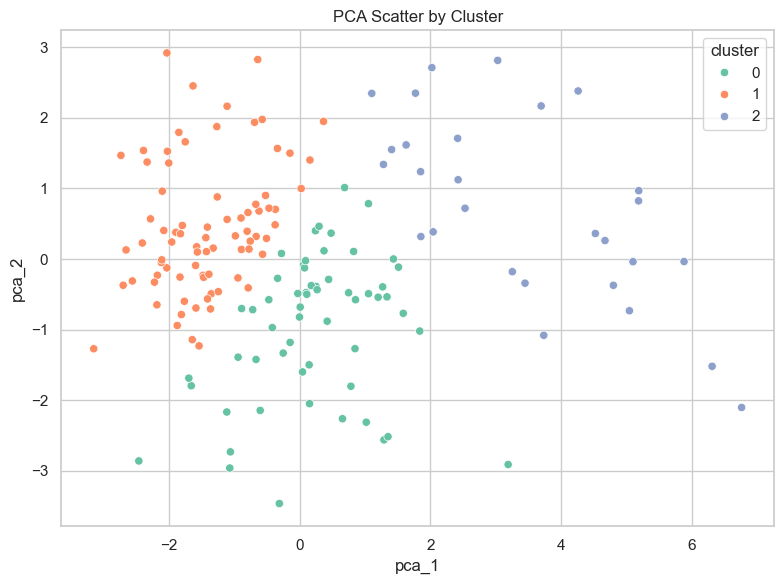

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_features, x='pca_1', y='pca_2', hue='cluster', palette='Set2')
plt.title('PCA Scatter by Cluster')
plt.tight_layout()
plt.show()